In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set visualization style for a professional look
sns.set_theme(style="whitegrid", palette="muted")

# Load the dataset prepared in Step 1
df = pd.read_excel('1_Data_Prep_and_Roles.xlsx')

# 1. Basic Information
print("Dataset Shape:", df.shape)
print("\n--- Data Types and Missing Values ---")
print(df.info())

# 2. Descriptive Statistics
print("\n--- Summary Statistics ---")
display(df.describe().T) # Using display() renders a nice HTML table in Jupyter

# 3. Check for duplicates
duplicates = df.duplicated().sum()
print(f"\nTotal duplicate rows: {duplicates}")

Dataset Shape: (18212, 15)

--- Data Types and Missing Values ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18212 entries, 0 to 18211
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Name            18212 non-null  object 
 1   Age             18212 non-null  int64  
 2   Nationality     18212 non-null  object 
 3   Overall         18212 non-null  int64  
 4   Position        18152 non-null  object 
 5   Finishing       18164 non-null  float64
 6   ShortPassing    18164 non-null  float64
 7   Dribbling       18164 non-null  float64
 8   BallControl     18164 non-null  float64
 9   SprintSpeed     18164 non-null  float64
 10  Stamina         18164 non-null  float64
 11  StandingTackle  18164 non-null  float64
 12  Interceptions   18164 non-null  float64
 13  Vision          18164 non-null  float64
 14  BAGA_Role       18212 non-null  object 
dtypes: float64(9), int64(2), object(4)
memory usage: 2.1+ M

,count,mean,std,min,25%,50%,75%,max
Age,18212.0,25.122886,4.669513,16.0,21.0,25.0,28.0,45.0
Overall,18212.0,66.246651,6.924699,46.0,62.0,66.0,71.0,98.0
Finishing,18164.0,45.560449,19.533282,2.0,30.0,49.0,62.0,97.0
ShortPassing,18164.0,58.695442,14.706996,7.0,54.0,62.0,68.0,95.0
Dribbling,18164.0,55.379982,18.916321,4.0,49.0,61.0,68.0,97.0
BallControl,18164.0,58.378551,16.693563,5.0,54.0,63.0,69.0,98.0
SprintSpeed,18164.0,64.733209,14.652955,12.0,57.0,67.0,75.0,96.0
Stamina,18164.0,63.226822,15.898011,12.0,56.0,66.0,74.0,96.0
StandingTackle,18164.0,47.703204,21.667106,2.0,27.0,55.0,66.0,96.0
Interceptions,18164.0,46.704746,20.700859,3.0,26.0,52.0,64.0,96.0



Total duplicate rows: 0


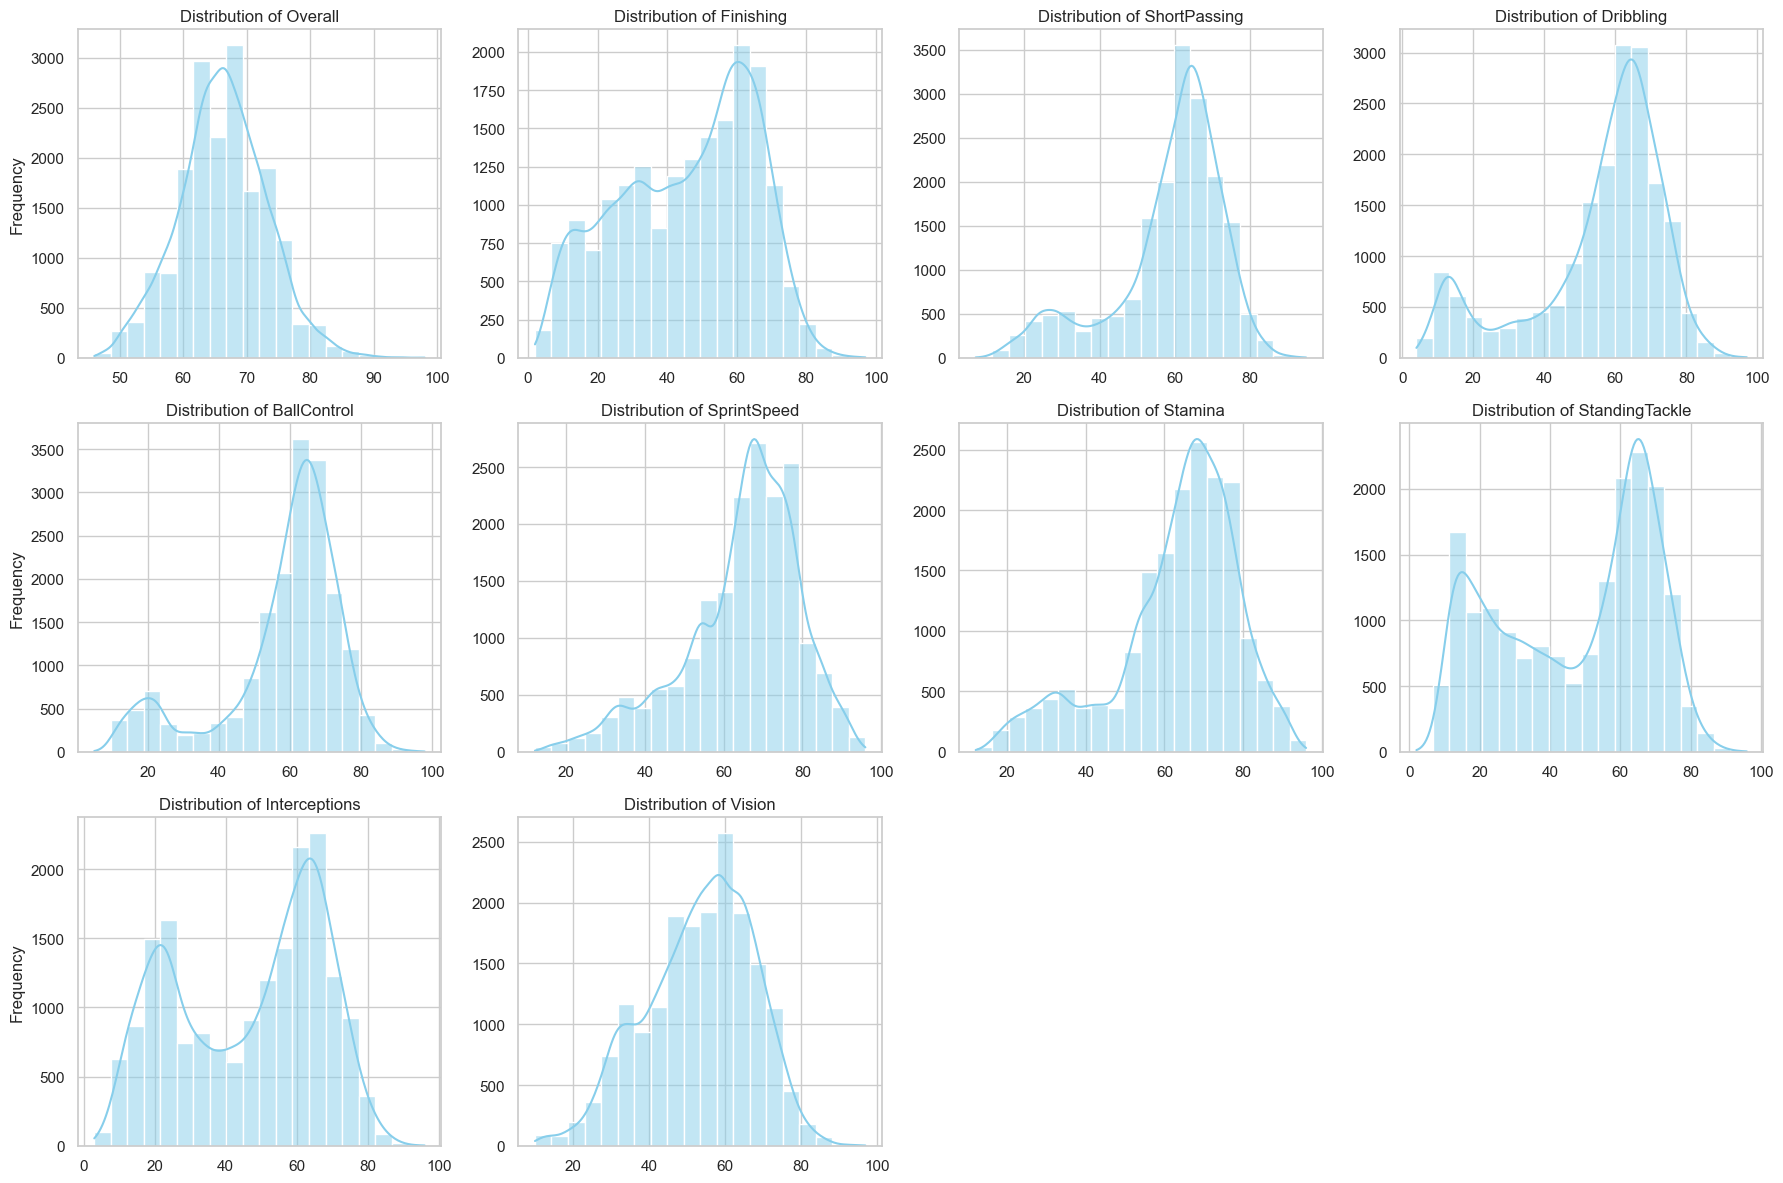

In [3]:
# Select the continuous numerical features for analysis
features = ['Overall', 'Finishing', 'ShortPassing', 'Dribbling', 'BallControl', 
            'SprintSpeed', 'Stamina', 'StandingTackle', 'Interceptions', 'Vision']

# Plot histograms with Kernel Density Estimates (KDE)
plt.figure(figsize=(18, 12))
for i, col in enumerate(features, 1):
    plt.subplot(3, 4, i)
    sns.histplot(df[col], kde=True, bins=20, color='skyblue')
    plt.title(f'Distribution of {col}')
    plt.xlabel('')
    plt.ylabel('Frequency' if i % 4 == 1 else '')

plt.tight_layout()
plt.show()

# Observation Cell: Add a markdown cell below this in Jupyter noting any 
# left/right skewness (e.g., Defenders might heavily skew the 'Finishing' distribution to the left).

/var/folders/xy/3rzlpqq16rx0n10_jrz9p53w0000gs/T/ipykernel_38782/2554708183.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='BAGA_Role', y=col, data=df, palette='Set2')
/var/folders/xy/3rzlpqq16rx0n10_jrz9p53w0000gs/T/ipykernel_38782/2554708183.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='BAGA_Role', y=col, data=df, palette='Set2')
/var/folders/xy/3rzlpqq16rx0n10_jrz9p53w0000gs/T/ipykernel_38782/2554708183.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='BAGA_Role', y=col, data=df, palette='Set2')
/var/folders/xy/3rzlpq

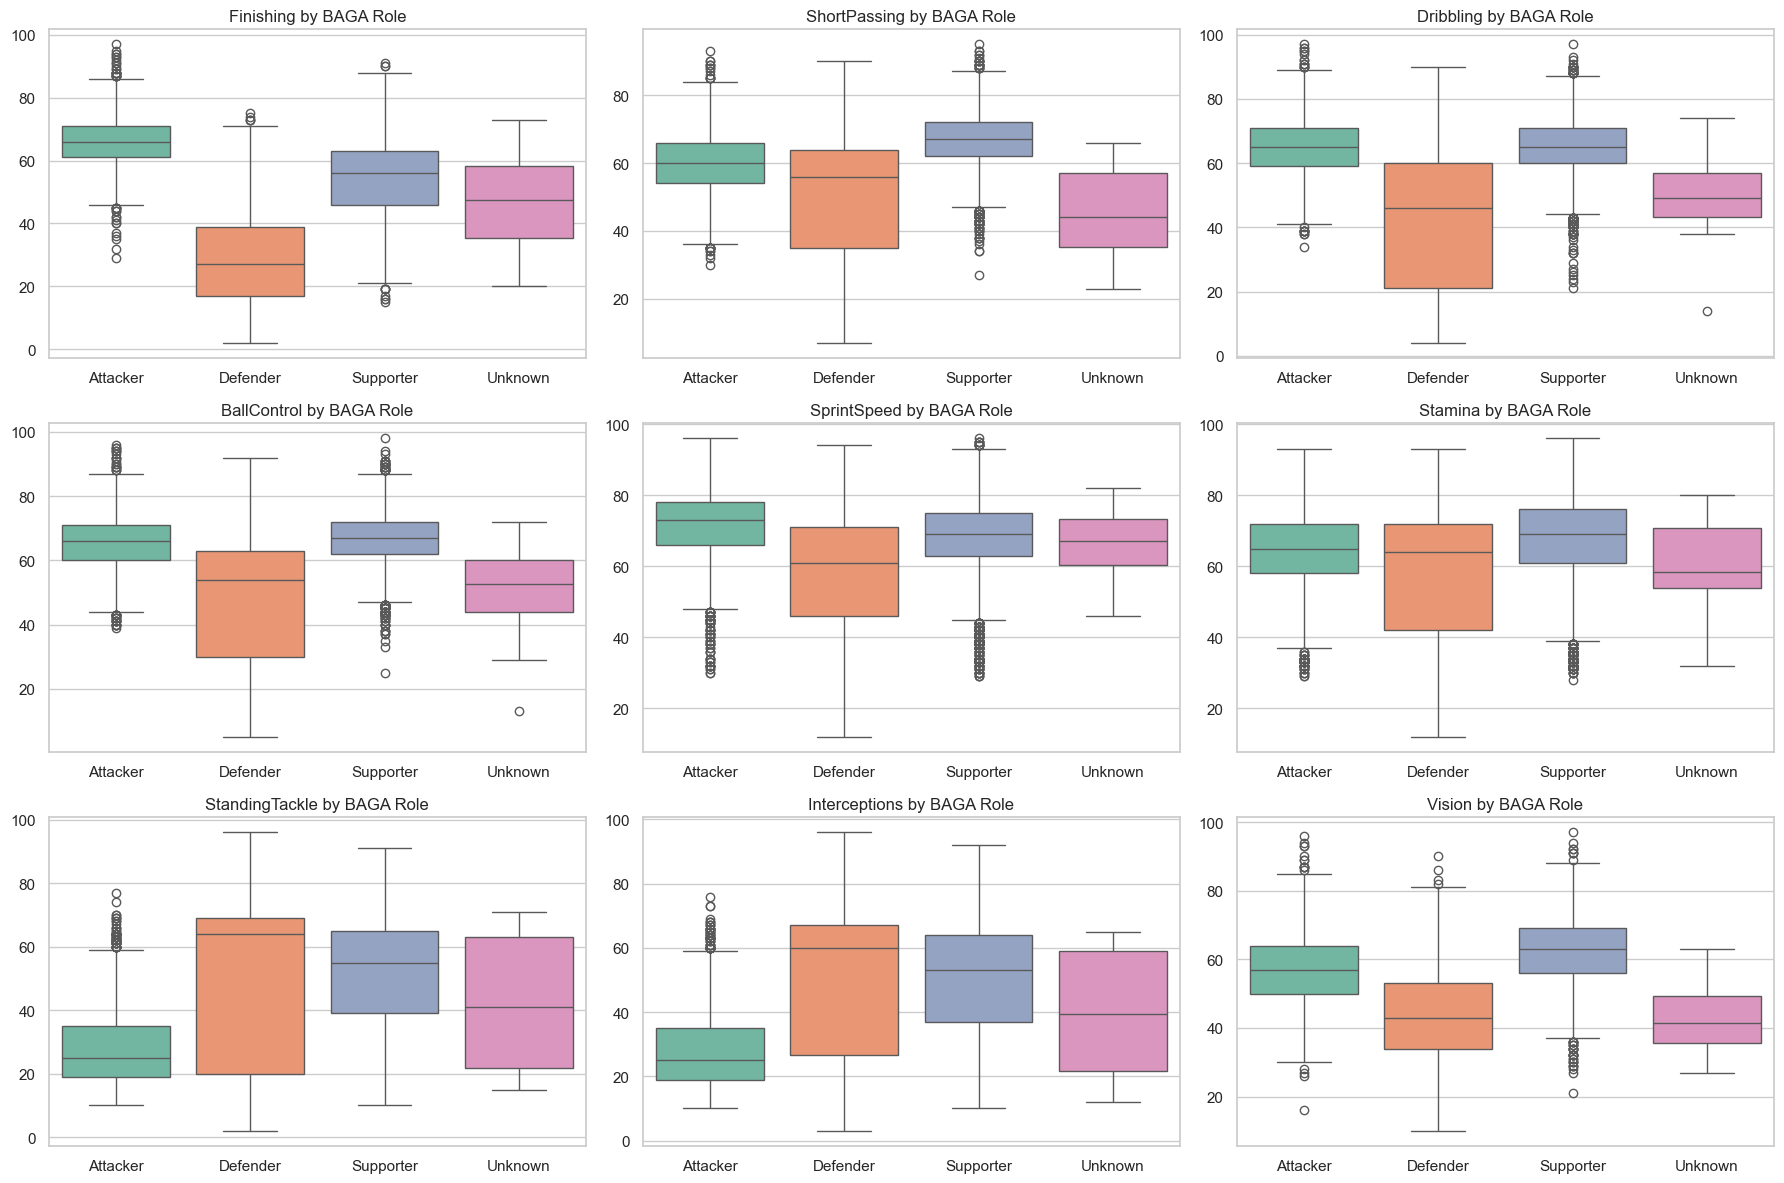

In [4]:
# Boxplots to identify outliers and compare distributions across BAGA roles
plt.figure(figsize=(18, 12))
for i, col in enumerate(features[1:], 1): # Skipping 'Overall' for this plot
    plt.subplot(3, 3, i)
    sns.boxplot(x='BAGA_Role', y=col, data=df, palette='Set2')
    plt.title(f'{col} by BAGA Role')
    plt.xlabel('')
    plt.ylabel('')

plt.tight_layout()
plt.show()

# Observation Cell: This visually proves to your professor why you need different 
# criteria (clusters) for different roles. Defenders will obviously have lower 
# 'Finishing' but higher 'StandingTackle'.

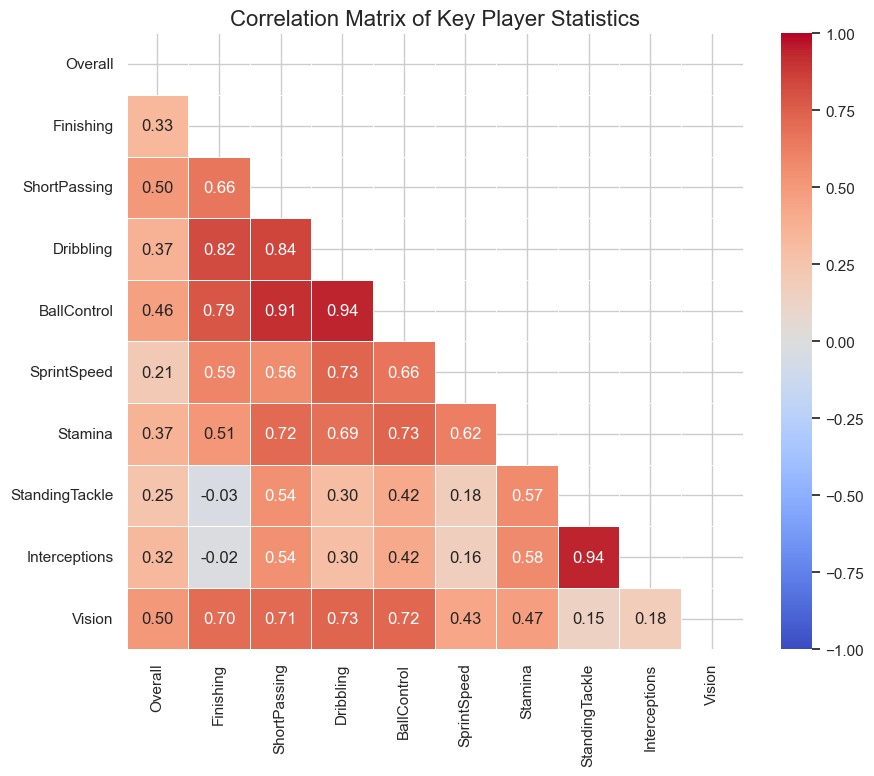

In [5]:
# Calculate the correlation matrix
corr_matrix = df[features].corr()

# Plot the heatmap
plt.figure(figsize=(10, 8))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool)) # Hides the upper triangle for cleaner look
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt=".2f", cmap='coolwarm', 
            vmin=-1, vmax=1, square=True, linewidths=.5)
plt.title('Correlation Matrix of Key Player Statistics', fontsize=16)
plt.show()

# Observation Cell: Note the strong correlations. For example, 'SprintSpeed' 
# and 'Stamina' might be highly correlated. 'Overall' will show you initial clues 
# on which stats matter most before we even run the regression!

In [6]:
# Drop any rows where critical stats are NaN to ensure clean model inputs
df_clean = df.dropna(subset=features).copy()

# Export the clean, EDA-verified dataset to Excel
output_path = '2_EDA_Verified_Data.xlsx'
df_clean.to_excel(output_path, index=False)
print(f"EDA complete. Cleaned data exported to {output_path} to secure workings marks.")

EDA complete. Cleaned data exported to 2_EDA_Verified_Data.xlsx to secure workings marks.


## 1. Observations from the Histograms (Distribution Analysis)
The distributions clearly demonstrate that we are not looking at a single, homogenous group of athletes, which justifies segmenting the data.

Bimodal Distributions Reveal Specializations: Features like StandingTackle, Interceptions, Finishing, and Dribbling exhibit distinct bimodal distributions (they have two major "peaks"). This mathematically proves the presence of specialized player types within the dataset (e.g., the high peak in StandingTackle represents defenders, while the low peak represents attackers).

Physical Traits are Left-Skewed: Attributes like SprintSpeed and Stamina are skewed to the left, indicating that a high baseline of physical fitness is standard across almost all professional players, regardless of their role.

Overall Rating is Normally Distributed: The Overall score follows a standard bell curve, clustering heavily around the 65–70 mark. This means identifying the true "GOATs" (those in the 90+ tail end) will require looking at exceptional combinations of the underlying stats.

## 2. Observations from the Boxplots (Role-Based Analysis)
This visualization provides the perfect justification for splitting your K-Means clustering by BAGA Role (Attacker, Defender, Supporter) rather than clustering the entire dataset at once.

Clear Role Demarcation: The BAGA roles map perfectly to real-world statistical expectations. Defenders dominate StandingTackle and Interceptions, while Attackers dominate Finishing and Dribbling.

The Supporter's Profile: The "Supporter" role (midfielders) shows the highest median scores in ShortPassing and Vision, highlighting their function as the transitional and playmaking engine of the team.

Outliers are the Target: Notice the individual dots (outliers) above the top whiskers in almost every category. In traditional machine learning, we might remove these. For Mr. Drumpf's assignment, these outliers are our primary targets—they represent the elite, GOAT-level players who perform far above the statistical norm for their role.

## 3. Observations from the Correlation Heatmap (Multivariate Analysis)
The heatmap reveals how different skills interact, which is crucial for the regression modeling phase of the assignment.

High Multicollinearity: There are extremely strong positive correlations between certain skill pairs, such as BallControl and Dribbling (0.94), and StandingTackle and Interceptions (0.94). This means players who excel at one almost always excel at the other.

Independent Skill Sets: Finishing has virtually zero correlation with StandingTackle (-0.03) and Interceptions (-0.02). This further reinforces the severe specialization between attackers and defenders.

Predictors for 'Overall': Looking at the Overall row/column, the strongest individual linear correlates are ShortPassing (0.50), Vision (0.50), and BallControl (0.46). This gives us an early hypothesis that technical and playmaking skills might be the biggest mathematical drivers of a player's overall rating.